# Residence Times and Transition Probabilities in Argyrodite

This tutorial demonstrates how to compute residence times and transition probabilities from a site-analysis trajectory. We reuse the argyrodite Li<sub>6</sub>PS<sub>5</sub>Cl dataset from [the previous tutorial](argyrodite_site_analysis.ipynb), so the setup code here is largely the same — see that tutorial for a detailed explanation of the reference structure and trajectory builder configuration.

## Prerequisites

This tutorial requires the following packages:

- `site-analysis`
- `pymatgen` (for reading VASP trajectories)
- `matplotlib`

This tutorial uses the same trajectory data as the argyrodite tutorial. If you have cloned the repository, the data files are already available in the `data/` subdirectory:

- `data/Li6PS5Cl_0p_XDATCAR.gz` — 0% anion site exchange (fully ordered)
- `data/Li6PS5Cl_50p_XDATCAR.gz` — 50% anion site exchange
- `data/Li6PS5Cl_100p_XDATCAR.gz` — 100% anion site exchange

The code examples below assume you are running this notebook from the `tutorials/` directory.

In [1]:
%config InlineBackend.figure_format = 'retina'

## Setting up the trajectory

We set up the reference structure and trajectory builder exactly as in the argyrodite tutorial. See [that tutorial](argyrodite_site_analysis.ipynb) for a full explanation of these steps.

In [2]:
from pymatgen.io.vasp import Xdatcar
from pymatgen.core import Structure, Lattice
import numpy as np
from site_analysis import TrajectoryBuilder

lattice = Lattice.cubic(a=10.155)

coords = np.array(
    [[0.5,     0.5,     0.5],     # P (type 0) - PS4 tetrahedra
     [0.9,     0.9,     0.6],     # type 1 (Li in reference)
     [0.77,    0.585,   0.585],   # type 2 (Mg in reference)
     [0.25,    0.25,    0.25],    # type 3 (Na in reference)
     [0.15,    0.15,    0.15],    # type 4 (Be in reference)
     [0.0,     0.183,   0.183],   # type 5 (K in reference)
     [0.0,     0.0,     0.0],     # S - anion position (4a site)
     [0.75,    0.25,    0.25],    # S - anion position (4c site)
     [0.11824, 0.11824, 0.38176]] # S - anion position (16e site)
)

reference_structure = Structure.from_spacegroup(
    sg="F-43m",
    lattice=lattice,
    species=['P', 'Li', 'Mg', 'Na', 'Be', 'K', 'S', 'S', 'S'],
    coords=coords) * [2, 2, 2]

In [3]:
site_types = {
    'type 1': 'Li',
    'type 2': 'Mg',
    'type 3': 'Na',
    'type 4': 'Be',
    'type 5': 'K',
}

def build_trajectory(structure):
    builder = TrajectoryBuilder()
    builder.with_reference_structure(reference_structure)
    builder.with_structure(structure)
    builder.with_mobile_species('Li')

    for label, species in site_types.items():
        builder.with_polyhedral_sites(
            centre_species=species, vertex_species='S',
            cutoff=3.0, n_vertices=4, label=label)

    builder.with_structure_alignment(align_species='P')
    builder.with_site_mapping(mapping_species=['S', 'Cl'])

    return builder.build()

We analyse all three disorder levels:

In [4]:
datasets = {
    '0%': 'data/Li6PS5Cl_0p_XDATCAR.gz',
    '50%': 'data/Li6PS5Cl_50p_XDATCAR.gz',
    '100%': 'data/Li6PS5Cl_100p_XDATCAR.gz',
}

trajectories = {}
for label, path in datasets.items():
    md_structures = Xdatcar(path).structures
    traj = build_trajectory(md_structures[0])
    traj.trajectory_from_structures(md_structures, progress=True)
    trajectories[label] = traj
    print(f"{label} disorder: {len(md_structures)} frames")

Analysing trajectory:   0%|          | 0/140 [00:00<?, ? steps/s]

0% disorder: 140 frames


Analysing trajectory:   0%|          | 0/140 [00:00<?, ? steps/s]

50% disorder: 140 frames


Analysing trajectory:   0%|          | 0/140 [00:00<?, ? steps/s]

100% disorder: 140 frames


## Computing residence times

Each site object has a `residence_times()` method that returns the lengths of consecutive runs where an atom remained at that site, measured in trajectory frames. For more details, see the [residence times guide](https://site-analysis.readthedocs.io/en/latest/guides/residence_times.html).

We focus on the three active site types (types 2, 4, and 5 — the others are essentially unoccupied in these simulations). First, let's look at the distributions of residence times across disorder levels:

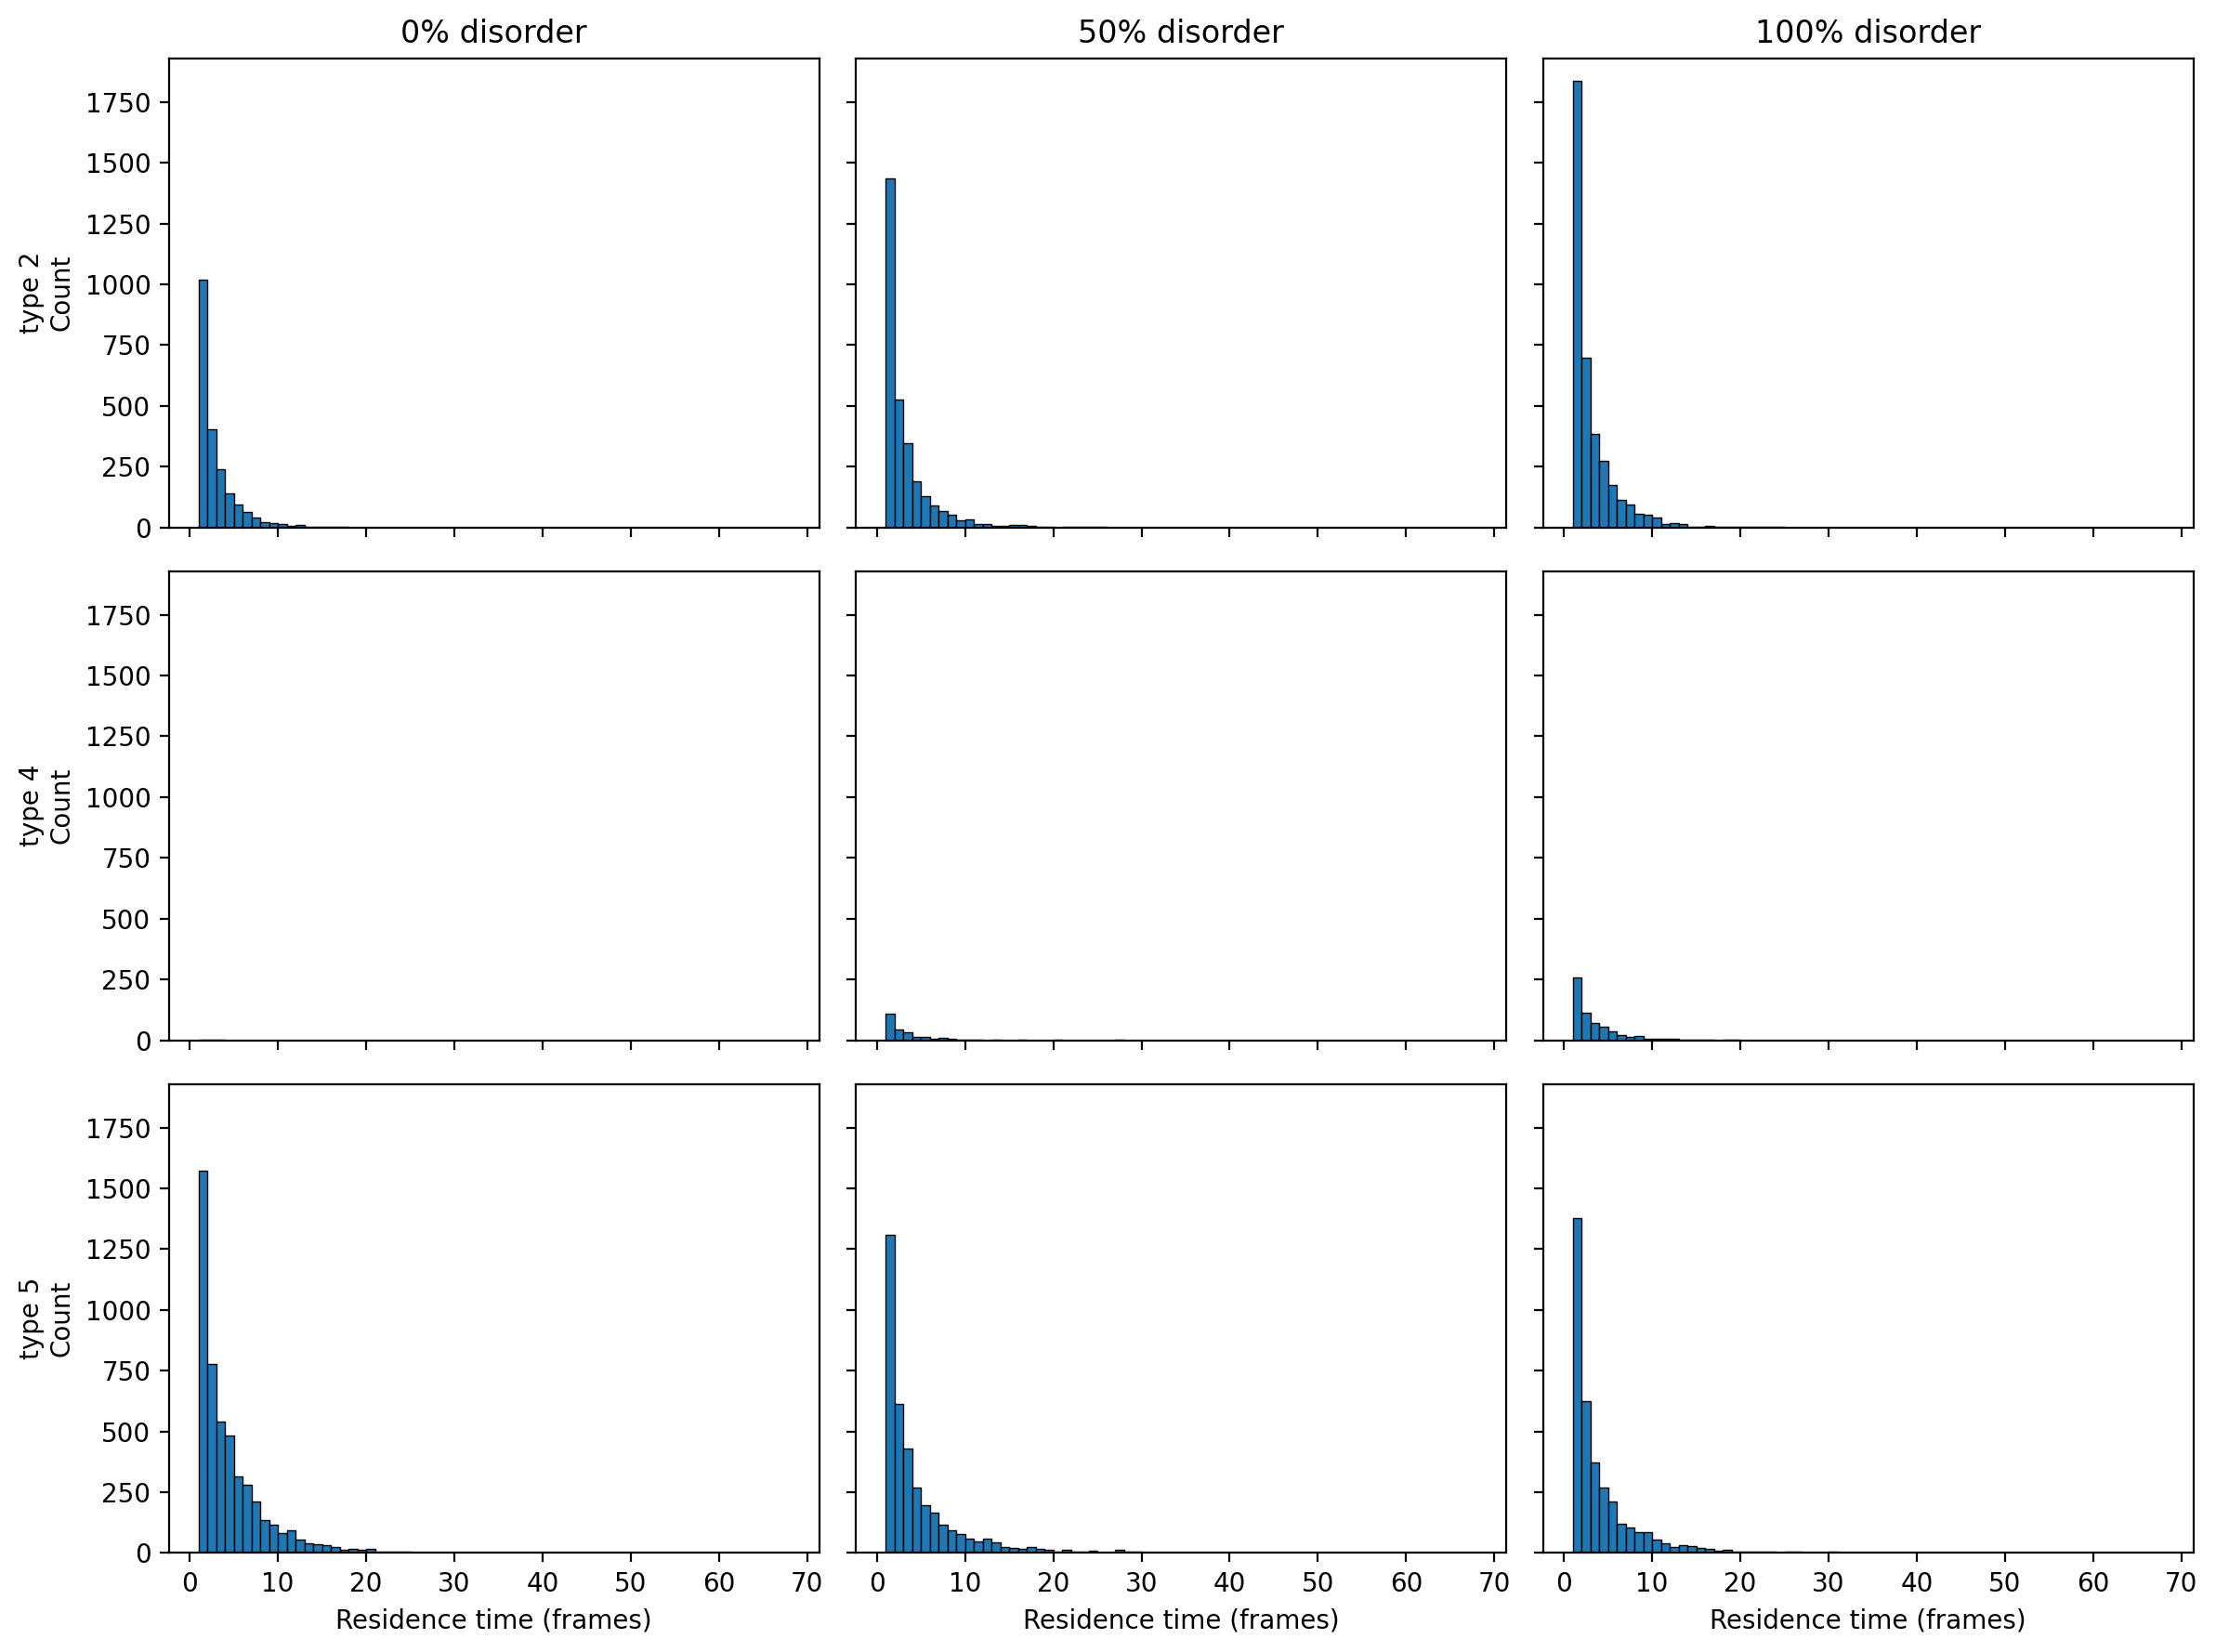

In [5]:
import matplotlib.pyplot as plt

site_labels = ['type 2', 'type 4', 'type 5']
disorder_levels = ['0%', '50%', '100%']

def residence_times_by_label(traj, filter_length=0):
    """Collect residence times grouped by site label."""
    result = {}
    for label in site_labels:
        times = []
        for site in traj.sites:
            if site.label == label:
                times.extend(site.residence_times(filter_length=filter_length))
        result[label] = times
    return result

fig, axes = plt.subplots(len(site_labels), len(disorder_levels),
                         figsize=(12, 9), sharex=True, sharey=True)

for j, disorder in enumerate(disorder_levels):
    residence_by_label = residence_times_by_label(trajectories[disorder])

    for i, label in enumerate(site_labels):
        ax = axes[i, j]
        times = residence_by_label[label]
        if times:
            ax.hist(times, bins='auto', edgecolor='black', linewidth=0.5)
        if i == 0:
            ax.set_title(f'{disorder} disorder')
        if j == 0:
            ax.set_ylabel(f'{label}\nCount')
        if i == len(site_labels) - 1:
            ax.set_xlabel('Residence time (frames)')

fig.tight_layout()
plt.show()

### Summary statistics

We can summarise these distributions by computing the mean residence time and number of occupation events for each site type:

In [6]:
for disorder, traj in trajectories.items():
    residence_by_label = residence_times_by_label(traj)

    print(f"\n{disorder} disorder:")
    for label in site_labels:
        times = residence_by_label[label]
        if times:
            arr = np.array(times)
            print(f"  {label}: mean residence time = {arr.mean():.1f} frames "
                  f"({len(arr)} occupation events)")
        else:
            print(f"  {label}: no occupation events")


0% disorder:
  type 2: mean residence time = 2.4 frames (2081 occupation events)
  type 4: mean residence time = 2.5 frames (2 occupation events)
  type 5: mean residence time = 4.1 frames (4892 occupation events)

50% disorder:
  type 2: mean residence time = 2.7 frames (2970 occupation events)
  type 4: mean residence time = 2.8 frames (242 occupation events)
  type 5: mean residence time = 4.3 frames (3682 occupation events)

100% disorder:
  type 2: mean residence time = 2.6 frames (3796 occupation events)
  type 4: mean residence time = 3.0 frames (613 occupation events)
  type 5: mean residence time = 3.7 frames (3549 occupation events)


### Effect of filtering

In molecular dynamics trajectories, atoms can briefly leave a site due to thermal fluctuations before returning. The `filter_length` parameter fills short gaps in the occupation sequence before computing run lengths. For more details, see the [residence times guide](https://site-analysis.readthedocs.io/en/latest/guides/residence_times.html). We demonstrate using the 50% disordered trajectory:

In [7]:
traj_50 = trajectories['50%']

for filter_length in [0, 1, 2]:
    residence_by_label = residence_times_by_label(traj_50, filter_length=filter_length)

    print(f"\nfilter_length={filter_length}:")
    for label in site_labels:
        times = residence_by_label[label]
        if times:
            arr = np.array(times)
            print(f"  {label}: mean residence time = {arr.mean():.1f} frames "
                  f"({len(arr)} occupation events)")


filter_length=0:
  type 2: mean residence time = 2.7 frames (2970 occupation events)
  type 4: mean residence time = 2.8 frames (242 occupation events)
  type 5: mean residence time = 4.3 frames (3682 occupation events)

filter_length=1:
  type 2: mean residence time = 3.9 frames (2177 occupation events)
  type 4: mean residence time = 3.7 frames (197 occupation events)
  type 5: mean residence time = 6.6 frames (2342 occupation events)

filter_length=2:
  type 2: mean residence time = 4.9 frames (1827 occupation events)
  type 4: mean residence time = 4.1 frames (181 occupation events)
  type 5: mean residence time = 8.3 frames (1879 occupation events)


## Transition probabilities

The `transition_probabilities_by_label()` method returns a row-normalised matrix showing the probability of transitioning from one site type to another. Each row sums to 1.0.

Since types 1 and 3 are essentially unoccupied, we filter to the three active site types:

In [ ]:
site_type_keys = ['type 2', 'type 4', 'type 5']

In [ ]:
for disorder, traj in trajectories.items():
    probs = traj.transition_probabilities_by_label().filter(site_type_keys)
    print(f"\n{disorder} disorder — transition probabilities:")
    display(probs)

The underlying counts are available via `transition_counts_by_label()`:

In [ ]:
for disorder, traj in trajectories.items():
    counts = traj.transition_counts_by_label().filter(site_type_keys)
    print(f"\n{disorder} disorder — transition counts:")
    display(counts)

### Visualising the transition matrices

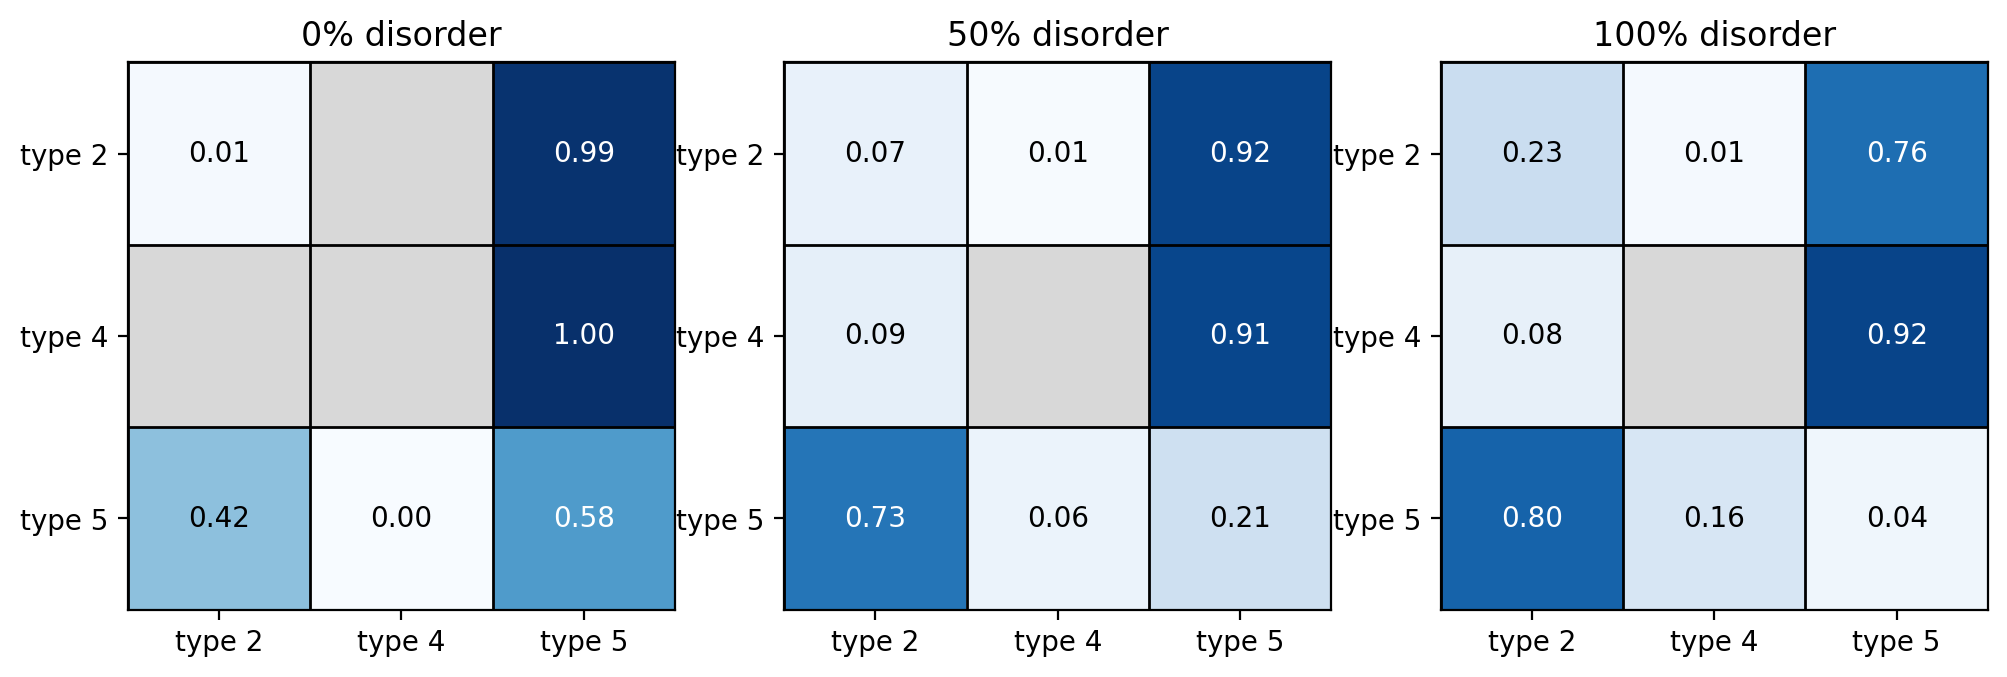

In [11]:
from plotting import heatmap, annotate_heatmap

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (disorder, traj) in zip(axes, trajectories.items()):
    probs = traj.transition_probabilities_by_label().filter(site_type_keys)
    labels = list(probs.keys)

    im = heatmap(probs.matrix, labels, labels, ax=ax, cmap='Blues')
    annotate_heatmap(im)

    ax.set_title(f'{disorder} disorder')

plt.show()